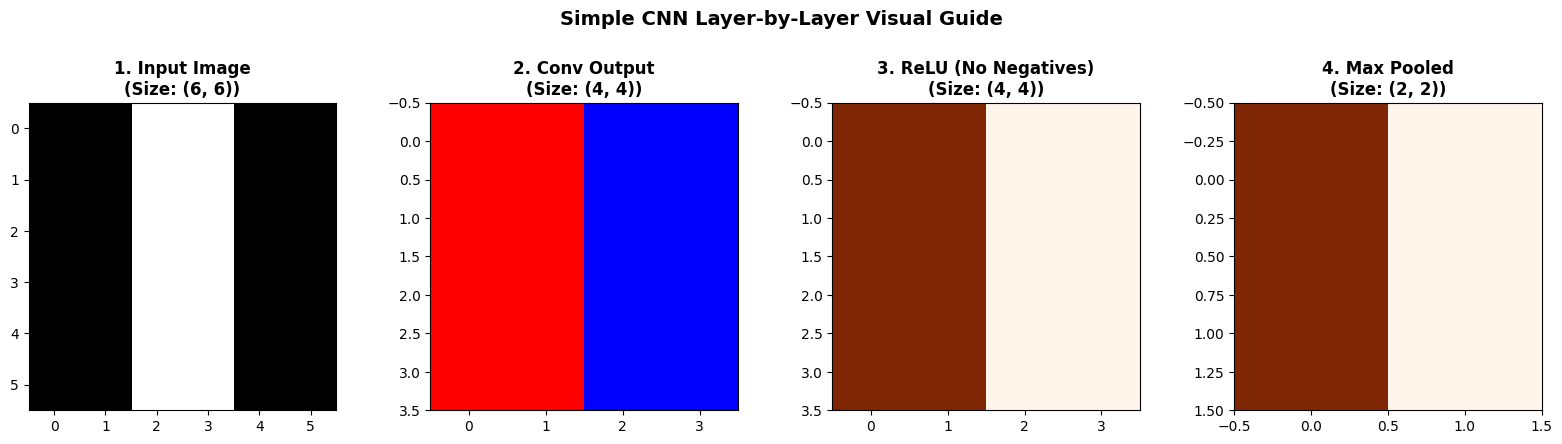

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CREATE A SIMPLE IMAGE (6x6 Grid with a vertical line in the middle)
image = np.array(
    [
        [0, 0, 1, 1, 0, 0],
        [0, 0, 1, 1, 0, 0],
        [0, 0, 1, 1, 0, 0],
        [0, 0, 1, 1, 0, 0],
        [0, 0, 1, 1, 0, 0],
        [0, 0, 1, 1, 0, 0],
    ],
    dtype=float,
)

# 2. DEFINE AN EDGE FILTER (3x3 Vertical Edge Detector)
kernel = np.array(
    [
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1],
    ],
    dtype=float,
)

# 3. STEP 1: CONVOLUTION (Sliding the filter over the image)
image_height, image_width = image.shape
kernel_height, kernel_width = kernel.shape

# Calculate output size: (6 - 3 + 1) = 4x4
conv_height = image_height - kernel_height + 1
conv_width = image_width - kernel_width + 1
feature_map = np.zeros((conv_height, conv_width))

# Loop through every possible position where the filter fits
for r in range(conv_height):
    for c in range(conv_width):
        # Extract the current 3x3 patch from the image
        image_patch = image[r : r + kernel_height, c : c + kernel_width]
        # Multiply patch by filter elements, and sum them up
        feature_map[r, c] = np.sum(image_patch * kernel)


# 4. STEP 2: ReLU ACTIVATION (Turn negative values into 0)
relu_map = np.maximum(0, feature_map)


# 5. STEP 3: MAX POOLING (Shrink the image using a 2x2 window with stride 2)
pool_size = 2
pool_height = conv_height // pool_size
pool_width = conv_width // pool_size
pooled_map = np.zeros((pool_height, pool_width))

for r in range(pool_height):
    for c in range(pool_width):
        # Find the starting index for our 2x2 block
        start_r = r * pool_size
        start_c = c * pool_size
        # Extract the 2x2 patch
        pool_patch = relu_map[start_r : start_r + pool_size, start_c : start_c + pool_size]
        # Take the maximum value in that patch
        pooled_map[r, c] = np.max(pool_patch)


# ── VISUALIZE THE PIPELINE ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot Original Image
axes[0].imshow(image, cmap="gray")
axes[0].set_title(f"1. Input Image\n(Size: {image.shape})", fontweight="bold")

# Plot Raw Convolution Output
axes[1].imshow(feature_map, cmap="bwr")
axes[1].set_title(f"2. Conv Output\n(Size: {feature_map.shape})", fontweight="bold")

# Plot ReLU Output
axes[2].imshow(relu_map, cmap="Oranges", vmin=0)
axes[2].set_title(f"3. ReLU (No Negatives)\n(Size: {relu_map.shape})", fontweight="bold")

# Plot Max Pooling Output
axes[3].imshow(pooled_map, cmap="Oranges", vmin=0)
axes[3].set_title(f"4. Max Pooled\n(Size: {pooled_map.shape})", fontweight="bold")

# Clean up layout display
for ax in axes:
    ax.grid(False)

plt.suptitle("Simple CNN Layer-by-Layer Visual Guide", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

Loaded input digit image shape: (8, 8)
Calculating convolution map...
Feature map shape : (6, 6)
Applying ReLU activation...
Calculating max pooling pass...
Pooled map shape   : (3, 3)


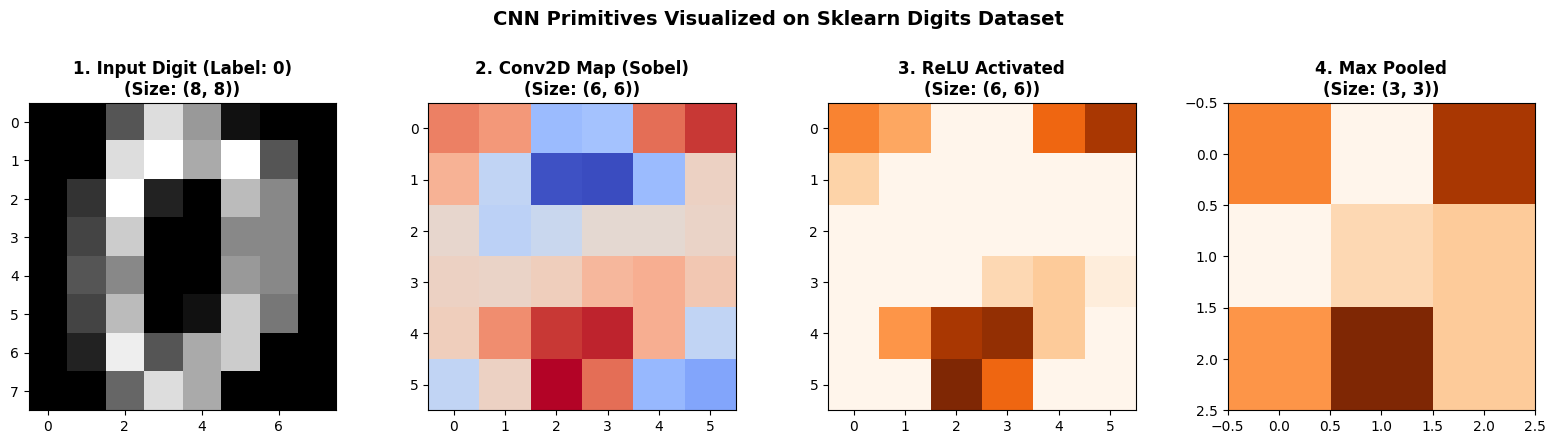

In [6]:
"""
Convolutional Neural Network (CNN) Primitives on the Digits Dataset
===================================================================
Demonstrates the core forward-pass primitives of a CNN on a real handwritten digit:
  1. Load an 8x8 digit image from sklearn
  2. 2-D convolution  (Sobel Horizontal Edge Detector)
  3. ReLU activation   (Saves positive edge responses)
  4. 2×2 max-pooling   (Reduces image size to 3x3)
"""

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

# ── 1. Load the Digits Dataset & Pick one Image ──────────────────────────────
digits = load_digits()

# Let's grab the very first image (it's a handwritten digit '0')
# Normalize pixel values to be between 0.0 and 1.0
image = digits.images[0] / 16.0
print(f"Loaded input digit image shape: {image.shape}")


# ── 2. CNN Primitives ─────────────────────────────────────────────────────────
def conv2d(img: np.ndarray, fltr: np.ndarray) -> np.ndarray:
    """Perform standard valid 2-D cross-correlation loop."""
    kH, kW = fltr.shape
    out_H = img.shape[0] - kH + 1
    out_W = img.shape[1] - kW + 1

    feature_map = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            feature_map[i, j] = np.sum(img[i : i + kH, j : j + kW] * fltr)
    return feature_map


def relu(z: np.ndarray) -> np.ndarray:
    """Apply ReLU activation element-wise: max(0, z)."""
    return np.maximum(0, z)


def max_pool2d(feature_map: np.ndarray, pool_size: int = 2) -> np.ndarray:
    """Apply 2-D max-pooling with stride equal to pool_size."""
    H, W = feature_map.shape
    out_H = H // pool_size
    out_W = W // pool_size

    pooled = np.zeros((out_H, out_W))
    for i in range(out_H):
        for j in range(out_W):
            row_start = i * pool_size
            col_start = j * pool_size
            patch = feature_map[
                row_start : row_start + pool_size,
                col_start : col_start + pool_size,
            ]
            pooled[i, j] = patch.max()
    return pooled


# ── 3. Define an Edge Detection Filter ────────────────────────────────────────
# Sobel Horizontal Edge Filter (Detects top and bottom boundaries of the digit)
kernel = np.array(
    [
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1],
    ],
    dtype=float,
)

# ── 4. Execute Forward Pipeline ───────────────────────────────────────────────
print("Calculating convolution map...")
f_map = conv2d(image, kernel)
print(f"Feature map shape : {f_map.shape}")

print("Applying ReLU activation...")
activated = relu(f_map)

print("Calculating max pooling pass...")
pooled = max_pool2d(activated, pool_size=2)
print(f"Pooled map shape   : {pooled.shape}")


# ── 5. Pipeline Visualization ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot 1: Source Handwritten Digit
axes[0].imshow(image, cmap="gray")
axes[0].set_title(f"1. Input Digit (Label: {digits.target[0]})\n(Size: {image.shape})", fontweight="bold")

# Plot 2: Raw Convolution (Highlighting horizontal edges)
axes[1].imshow(f_map, cmap="coolwarm")
axes[1].set_title(f"2. Conv2D Map (Sobel)\n(Size: {f_map.shape})", fontweight="bold")

# Plot 3: ReLU Activated (Negative values removed)
axes[2].imshow(activated, cmap="Oranges", vmin=0)
axes[2].set_title(f"3. ReLU Activated\n(Size: {activated.shape})", fontweight="bold")

# Plot 4: Max Pooling (Downsampled structural summary)
axes[3].imshow(pooled, cmap="Oranges", vmin=0)
axes[3].set_title(f"4. Max Pooled\n(Size: {pooled.shape})", fontweight="bold")

# Add layout styling and turn off pixel axes lines for clarity
for ax in axes:
    ax.grid(False)

plt.suptitle("CNN Primitives Visualized on Sklearn Digits Dataset", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()